In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.debugger import set_trace
from config import parse_args
args = parse_args("",None)   
import sys
#sys.path.insert(0, args.worktree) 
sys.path.insert(0,  "/home/kim2712/Desktop/research/BGAN/BGAN") 

from BGAN_deep_critic import DBGAN_mix as BGAN
#from BGAN_double_deep_critic import double_DBGAN as BGAN
#from BGAN import BGAN

from _data.gaussian_conjugate import posterior_sampler, forward_sampler, X_forward_sampler
from os.path import join
import pathlib

ModuleNotFoundError: No module named 'torch'

In [11]:
HPARAM = {"nu":args.nu, "sigma0_sq":args.sigma0_sq, 
          "mu0":args.mu0,"kappa":args.kappa}

args.epoch = 30
args.n_sample=20

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns

nsample =args.n_sample
x_obs=1 

observed_data=np.array([x_obs for _ in range(nsample)])
theta, sigma_sq = posterior_sampler(X = observed_data,
                                        batch_size=300, 
                                        h_param = HPARAM)
true = np.stack([theta,sigma_sq],1)
x_true = torch.tensor(np.repeat(observed_data.reshape(1, nsample, 1), 300, axis=0), dtype=torch.float).cuda()

In [13]:
def plot(self):
    n_row,n_col = 1,2
    fig,axis = plt.subplots(n_row, n_col, figsize=(4*n_col,4*n_row), sharex=True, sharey=True)
    #set_trace()
    sample = self.sampler(observed_data.reshape(1,-1,1), 300, 
                            shaper = lambda X: torch.from_numpy(X).float().repeat(300, 1,1))
    #sample = self.sampler(observed_data.reshape(1,-1), 300,shaper = lambda X: torch.from_numpy(X).float().repeat(300, 1))
    
    sample += torch.randn(size=sample.shape)*0.0001 

    ax = axis[0] 
    sns.kdeplot(x=true[:,0], y=true[:,1], ax=ax, fill=True, color="orange")
    ax = axis[1] 
    sns.kdeplot(x=true[:,0], y=true[:,1], ax=ax, fill=True, 
                color="orange", alpha= 0.3) 
    sns.kdeplot(x=sample[:,0], y=sample[:,1], ax=ax, fill=False)
    plt.show()

In [14]:
def simulator(batch_size, np_random=None):
        n_samples=args.n_sample
        h_param = HPARAM
        Theta,X =  forward_sampler(n = n_samples, 
                        batch_size=batch_size,
                        h_param=h_param, as_torch = True, np_random=np_random)
        return Theta, X.unsqueeze(-1)
    
method = BGAN(simulator=simulator, 
             epoch=args.epoch,
             x_dim = 1,
             x_length = args.n_sample,
             theta_dim=2,n_iter=100,
             batch_size = args.batch_size,
             f1_dim =args.n_sample, f2_dim=0, Q_freq = 0, 
             critic_lr = 0.0003, generator_lr = 0.0003, inner_lr = 0.001,
              
              factor=128, f1_layers =2,
             common_factor=128,
              common_layers = 2,hidden_layers=2,
              d_hidden=128
              )
#factor: 16, 32, 64, 128
#f1_layers: 0,1,2
#common_layers: 2,3
#hidden_layers: 0,1,2
#d_hidden: 16, 32, 64, 128
#common_factor: 16 32 64 128

In [15]:
method.generator, method.critic

(Generator(
   (layers): ModuleList(
     (0): Linear(in_features=22, out_features=128, bias=True)
     (1): Linear(in_features=128, out_features=128, bias=True)
     (2): Linear(in_features=128, out_features=2, bias=True)
   )
   (activation): LeakyReLU(negative_slope=0.1)
   (ss): Auto_ss(
     (f1): DeepSets(
       (common_feature_net): MLP(
         (non_linear): LeakyReLU(negative_slope=0.1)
         (dropout): Dropout(p=0, inplace=False)
         (layers): ModuleList(
           (0): Linear(in_features=3, out_features=128, bias=True)
           (1): Linear(in_features=128, out_features=128, bias=True)
           (2): Linear(in_features=128, out_features=128, bias=True)
           (3): Linear(in_features=128, out_features=20, bias=True)
         )
       )
       (next_net): MLP(
         (non_linear): LeakyReLU(negative_slope=0.1)
         (dropout): Dropout(p=0, inplace=False)
         (layers): ModuleList(
           (0): Linear(in_features=20, out_features=128, bias=True)
   

In [16]:
method.w_regul=0.1

Epoch 0
Epoch 1
Epoch 2
Epoch 3


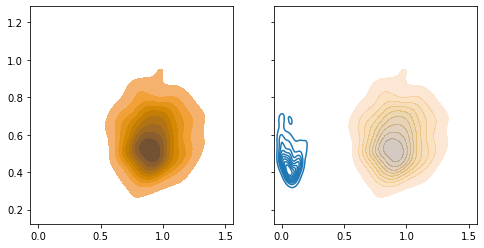

{'epoch': 3, 'iter': 95, 'mmd': 0.8, 'loss': -0.769}
Epoch 2
Epoch 3
Epoch 4
Epoch 5


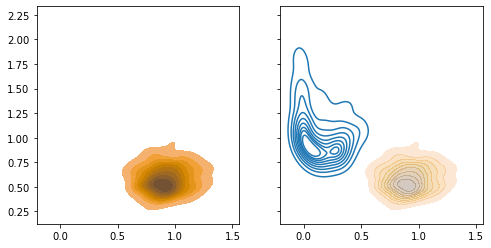

{'epoch': 5, 'iter': 95, 'mmd': 0.376, 'loss': -1.716}
Epoch 4
Epoch 5
Epoch 6
Epoch 7


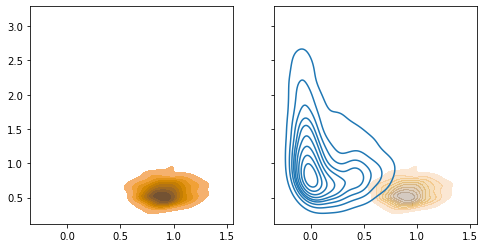

{'epoch': 7, 'iter': 95, 'mmd': 0.295, 'loss': -1.091}
Epoch 6
Epoch 7
Epoch 8
Epoch 9


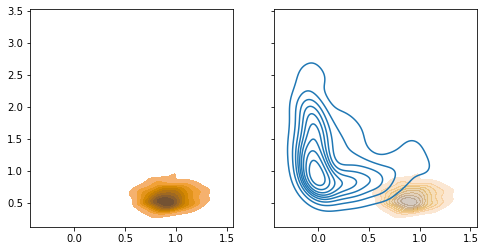

{'epoch': 9, 'iter': 95, 'mmd': 0.309, 'loss': -0.935}
Epoch 8
Epoch 9
Epoch 10
Epoch 11


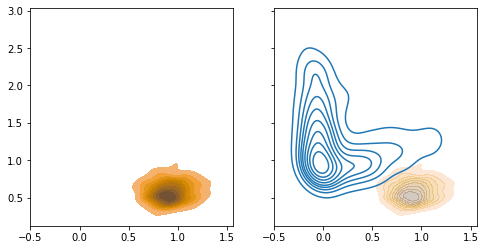

{'epoch': 11, 'iter': 95, 'mmd': 0.304, 'loss': -1.102}
Epoch 10
Epoch 11
Epoch 12
Epoch 13


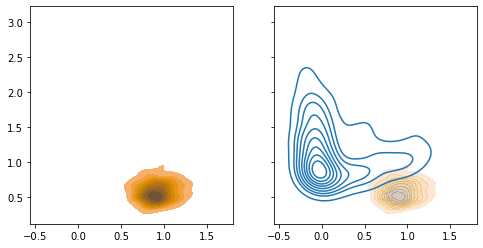

{'epoch': 13, 'iter': 95, 'mmd': 0.342, 'loss': -1.126}
Epoch 12
Epoch 13
Epoch 14
Epoch 15


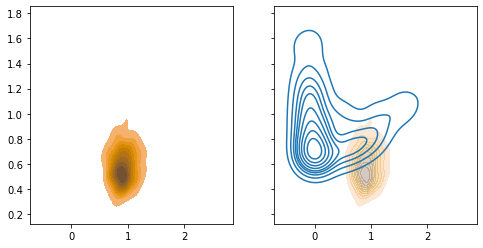

{'epoch': 15, 'iter': 95, 'mmd': 0.315, 'loss': -1.341}
Epoch 14
Epoch 15
Epoch 16
Epoch 17


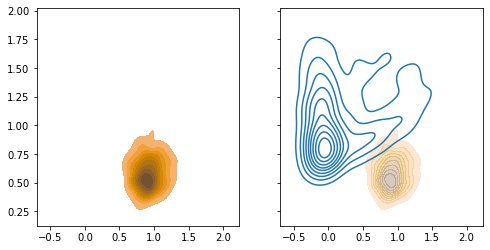

{'epoch': 17, 'iter': 95, 'mmd': 0.392, 'loss': -0.795}
Epoch 16
Epoch 17
Epoch 18
Epoch 19


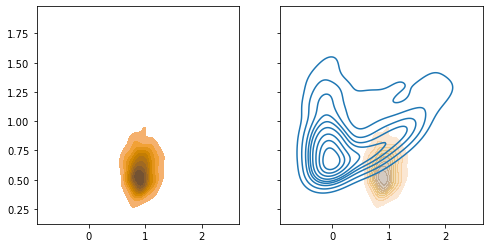

{'epoch': 19, 'iter': 95, 'mmd': 0.331, 'loss': -1.112}
Epoch 18
Epoch 19
Epoch 20
Epoch 21


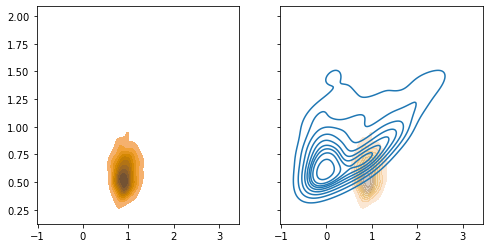

{'epoch': 21, 'iter': 95, 'mmd': 0.256, 'loss': -0.899}
Epoch 20
Epoch 21
Epoch 22
Epoch 23


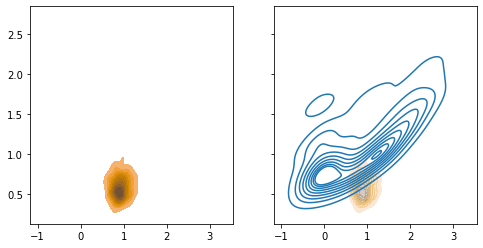

{'epoch': 23, 'iter': 95, 'mmd': 0.239, 'loss': -1.139}
Epoch 22
Epoch 23
Epoch 24
Epoch 25


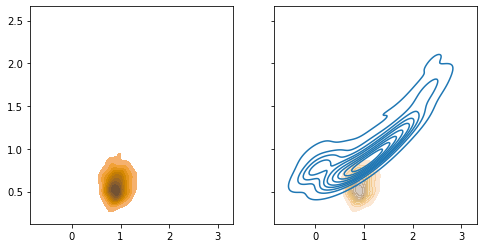

{'epoch': 25, 'iter': 95, 'mmd': 0.222, 'loss': -0.671}
Epoch 24
Epoch 25
Epoch 26
Epoch 27


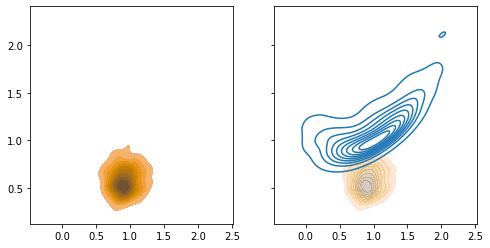

{'epoch': 27, 'iter': 95, 'mmd': 0.308, 'loss': -0.894}
Epoch 26
Epoch 27
Epoch 28
Epoch 29


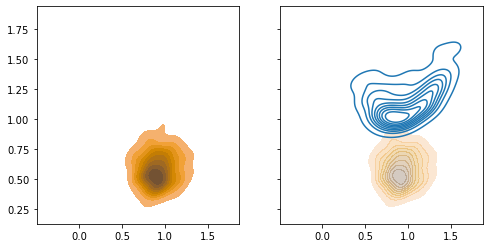

{'epoch': 29, 'iter': 95, 'mmd': 0.374, 'loss': -0.652}
Epoch 28
Epoch 29
Epoch 30
Epoch 31


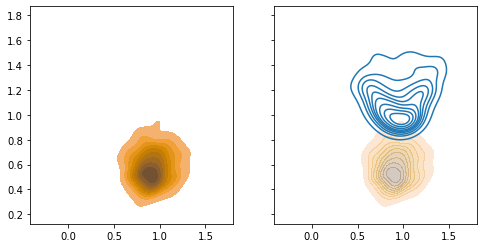

{'epoch': 31, 'iter': 95, 'mmd': 0.391, 'loss': 0.468}
Epoch 30
Epoch 31
Epoch 32
Epoch 33


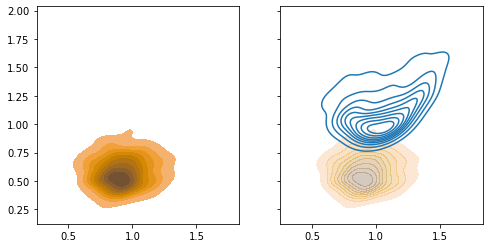

{'epoch': 33, 'iter': 95, 'mmd': 0.379, 'loss': -0.037}
Epoch 32
Epoch 33
Epoch 34
Epoch 35


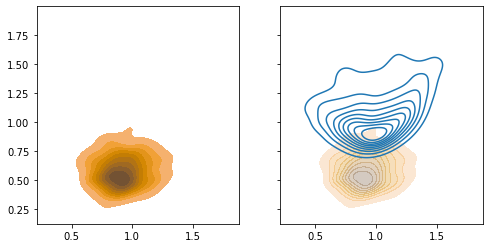

{'epoch': 35, 'iter': 95, 'mmd': 0.337, 'loss': -0.176}
Epoch 34
Epoch 35
Epoch 36
Epoch 37


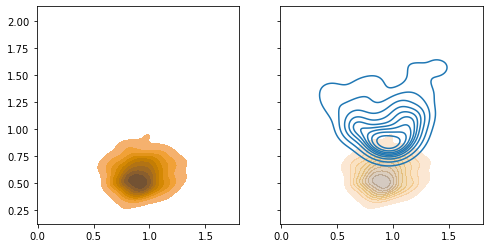

{'epoch': 37, 'iter': 95, 'mmd': 0.333, 'loss': -0.323}
Epoch 36
Epoch 37
Epoch 38
Epoch 39


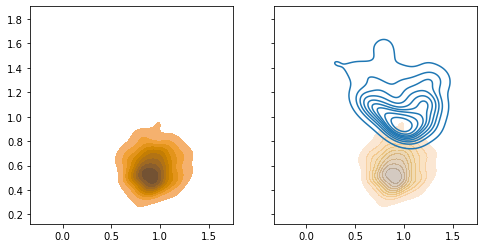

{'epoch': 39, 'iter': 95, 'mmd': 0.358, 'loss': -0.635}
Epoch 38
Epoch 39
Epoch 40
Epoch 41


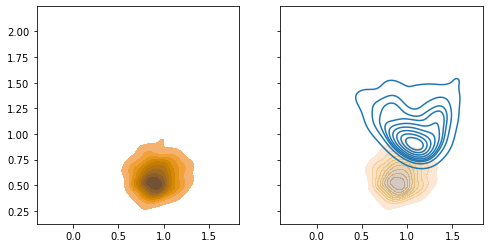

{'epoch': 41, 'iter': 95, 'mmd': 0.357, 'loss': -0.113}
Epoch 40
Epoch 41
Epoch 42
Epoch 43


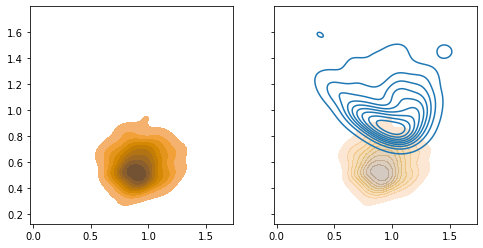

{'epoch': 43, 'iter': 95, 'mmd': 0.323, 'loss': -0.008}
Epoch 42
Epoch 43
Epoch 44
Epoch 45


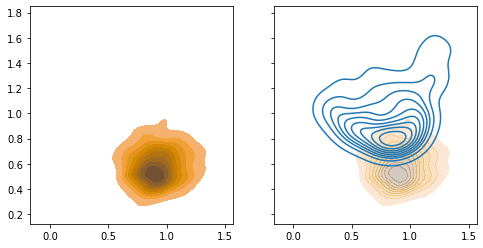

{'epoch': 45, 'iter': 95, 'mmd': 0.268, 'loss': -0.105}
Epoch 44
Epoch 45
Epoch 46
Epoch 47


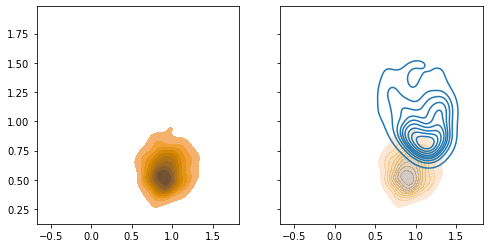

{'epoch': 47, 'iter': 95, 'mmd': 0.329, 'loss': -0.34}
Epoch 46
Epoch 47
Epoch 48
Epoch 49


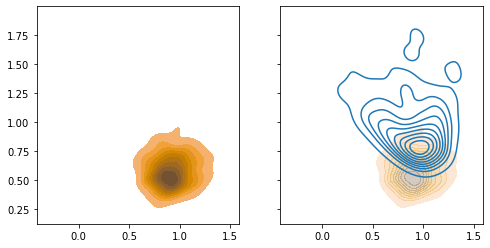

{'epoch': 49, 'iter': 95, 'mmd': 0.265, 'loss': -0.193}
Epoch 48
Epoch 49
Epoch 50
Epoch 51


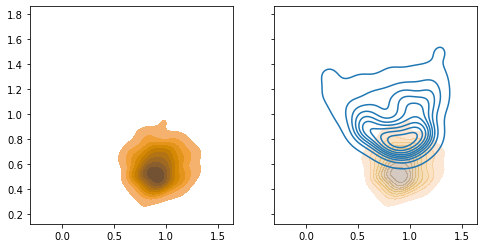

{'epoch': 51, 'iter': 95, 'mmd': 0.258, 'loss': 0.601}
Epoch 50
Epoch 51
Epoch 52
Epoch 53


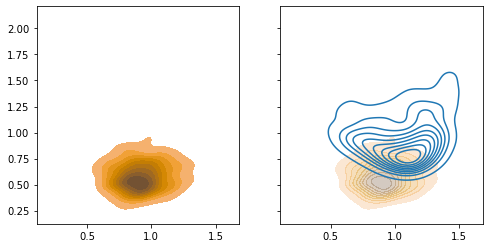

{'epoch': 53, 'iter': 95, 'mmd': 0.285, 'loss': 0.067}
Epoch 52
Epoch 53
Epoch 54
Epoch 55


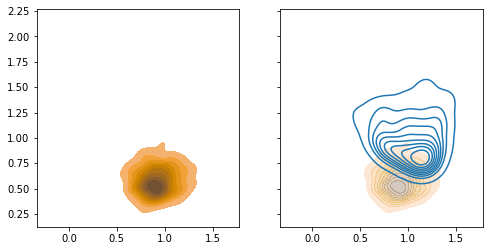

{'epoch': 55, 'iter': 95, 'mmd': 0.291, 'loss': -1.113}
Epoch 54
Epoch 55
Epoch 56
Epoch 57


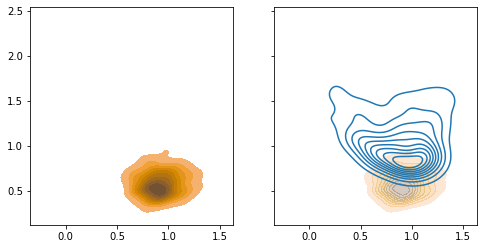

{'epoch': 57, 'iter': 95, 'mmd': 0.28, 'loss': 0.419}
Epoch 56
Epoch 57
Epoch 58
Epoch 59


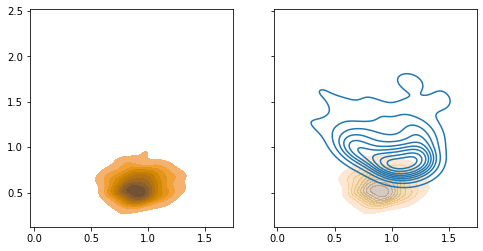

{'epoch': 59, 'iter': 95, 'mmd': 0.276, 'loss': 3.424}
Epoch 58
Epoch 59
Epoch 60
Epoch 61


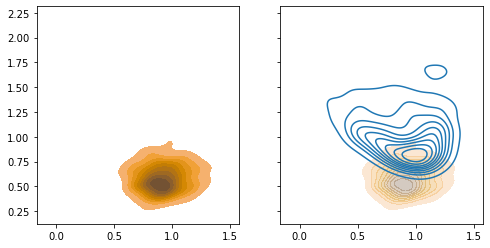

{'epoch': 61, 'iter': 95, 'mmd': 0.274, 'loss': -0.364}
Epoch 60
Epoch 61
Epoch 62
Epoch 63


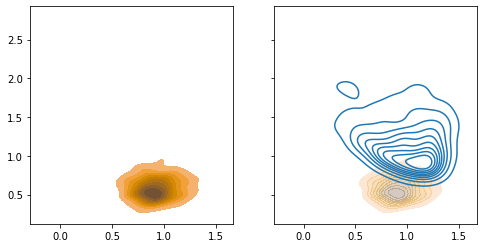

{'epoch': 63, 'iter': 95, 'mmd': 0.311, 'loss': 4.637}
Epoch 62
Epoch 63
Epoch 64
Epoch 65


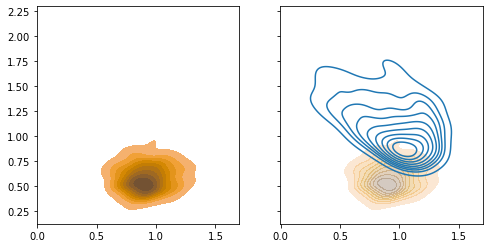

{'epoch': 65, 'iter': 95, 'mmd': 0.316, 'loss': 3.095}
Epoch 64
Epoch 65
Epoch 66
Epoch 67


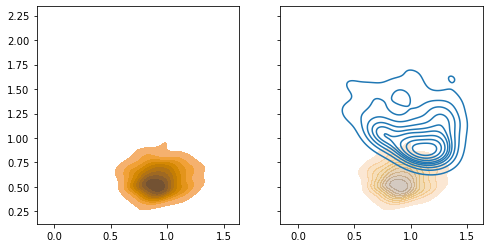

{'epoch': 67, 'iter': 95, 'mmd': 0.334, 'loss': 3.871}
Epoch 66
Epoch 67
Epoch 68
Epoch 69


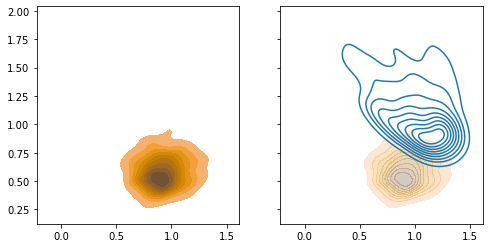

{'epoch': 69, 'iter': 95, 'mmd': 0.323, 'loss': -0.487}
Epoch 68
Epoch 69
Epoch 70
Epoch 71


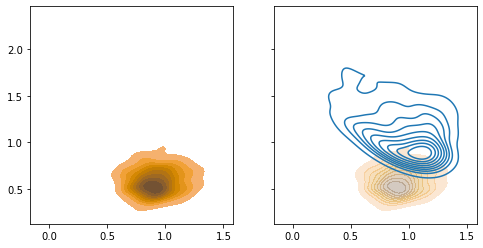

{'epoch': 71, 'iter': 95, 'mmd': 0.309, 'loss': -1.876}
Epoch 70
Epoch 71
Epoch 72
Epoch 73


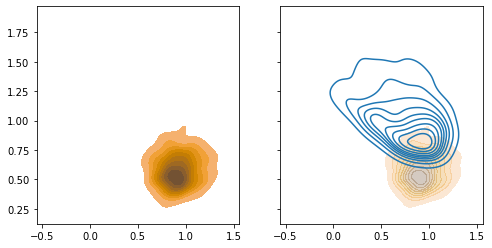

{'epoch': 73, 'iter': 95, 'mmd': 0.263, 'loss': -3.583}
Epoch 72
Epoch 73
Epoch 74
Epoch 75


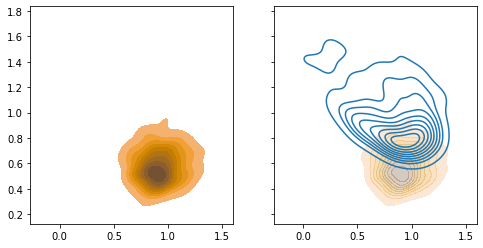

{'epoch': 75, 'iter': 95, 'mmd': 0.245, 'loss': -0.332}
Epoch 74
Epoch 75
Epoch 76
Epoch 77


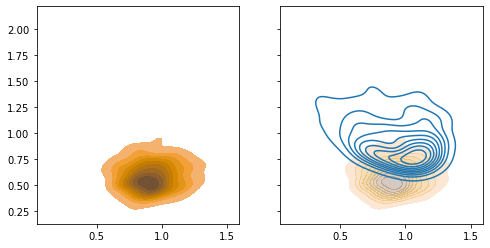

{'epoch': 77, 'iter': 95, 'mmd': 0.241, 'loss': -5.668}
Epoch 76
Epoch 77
Epoch 78
Epoch 79


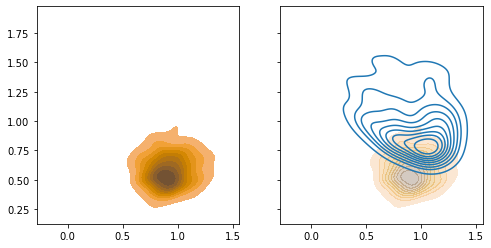

{'epoch': 79, 'iter': 95, 'mmd': 0.264, 'loss': 4.539}
Epoch 78
Epoch 79
Epoch 80
Epoch 81


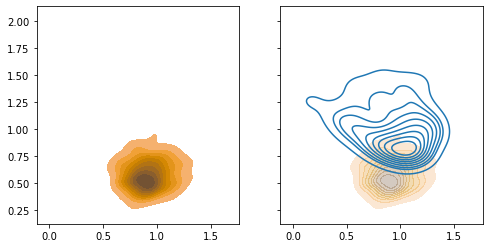

{'epoch': 81, 'iter': 95, 'mmd': 0.286, 'loss': 0.719}
Epoch 80
Epoch 81
Epoch 82
Epoch 83


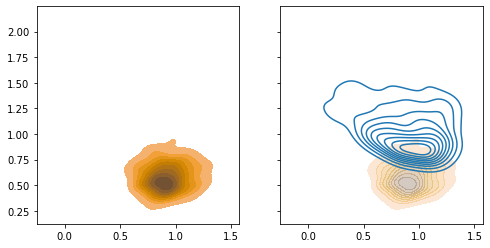

{'epoch': 83, 'iter': 95, 'mmd': 0.29, 'loss': -2.399}
Epoch 82
Epoch 83
Epoch 84
Epoch 85


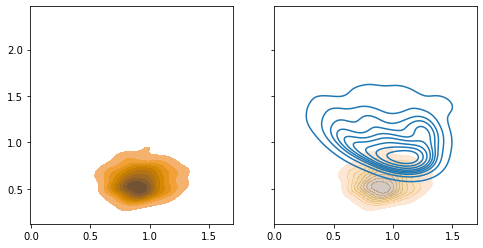

{'epoch': 85, 'iter': 95, 'mmd': 0.285, 'loss': -1.183}
Epoch 84
Epoch 85
Epoch 86
Epoch 87


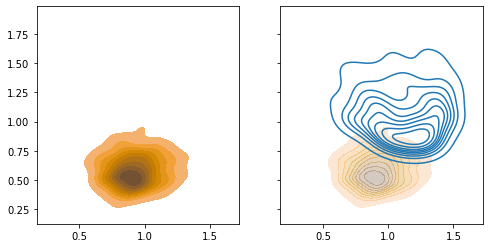

{'epoch': 87, 'iter': 95, 'mmd': 0.323, 'loss': 0.021}
Epoch 86
Epoch 87
Epoch 88
Epoch 89


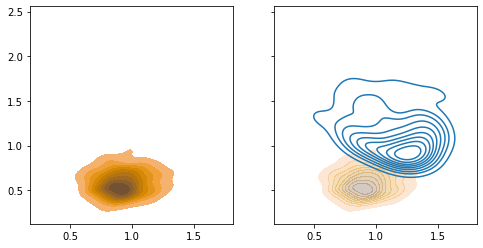

{'epoch': 89, 'iter': 95, 'mmd': 0.355, 'loss': 0.137}
Epoch 88
Epoch 89
Epoch 90
Epoch 91


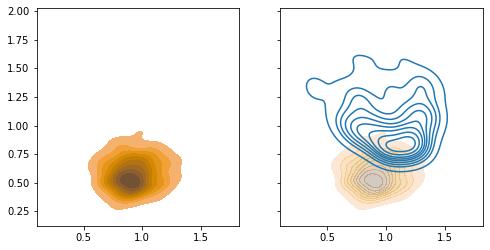

{'epoch': 91, 'iter': 95, 'mmd': 0.286, 'loss': -0.993}
Epoch 90
Epoch 91
Epoch 92
Epoch 93


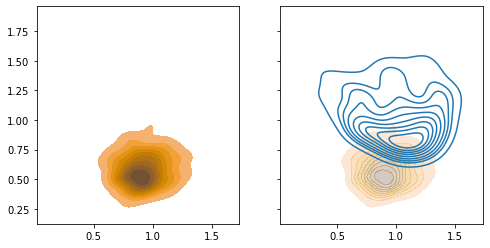

{'epoch': 93, 'iter': 95, 'mmd': 0.282, 'loss': -1.251}
Epoch 92
Epoch 93
Epoch 94
Epoch 95


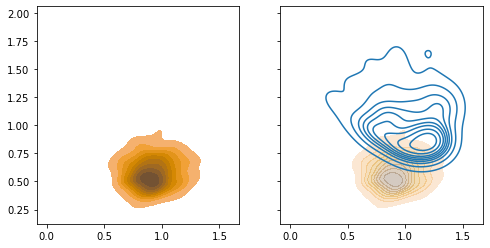

{'epoch': 95, 'iter': 95, 'mmd': 0.288, 'loss': -1.065}
Epoch 94
Epoch 95
Epoch 96
Epoch 97


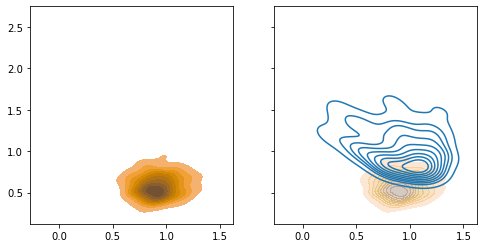

{'epoch': 97, 'iter': 95, 'mmd': 0.263, 'loss': -3.562}
Epoch 96
Epoch 97
Epoch 98
Epoch 99


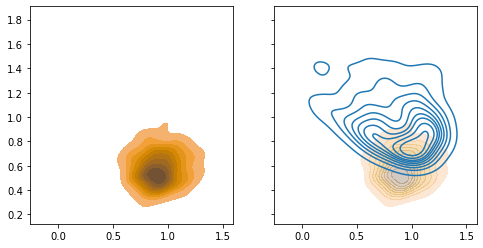

{'epoch': 99, 'iter': 95, 'mmd': 0.203, 'loss': 1.023}
Epoch 98
Epoch 99
Epoch 100
Epoch 101


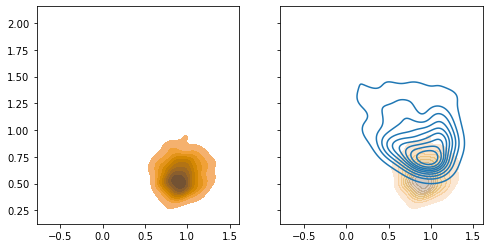

{'epoch': 101, 'iter': 95, 'mmd': 0.202, 'loss': 1.787}
Epoch 100
Epoch 101
Epoch 102
Epoch 103


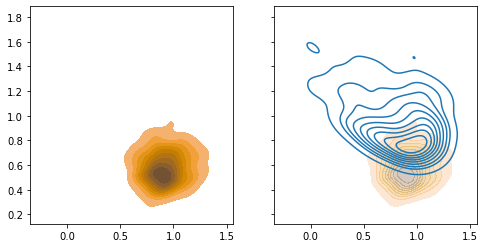

{'epoch': 103, 'iter': 95, 'mmd': 0.211, 'loss': -2.445}
Epoch 102
Epoch 103
Epoch 104
Epoch 105


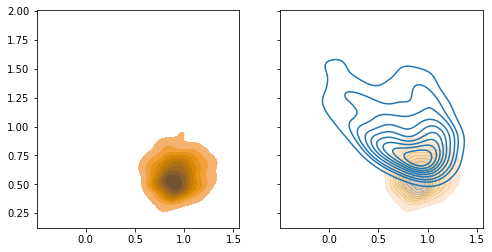

{'epoch': 105, 'iter': 95, 'mmd': 0.185, 'loss': -2.105}
Epoch 104
Epoch 105
Epoch 106
Epoch 107


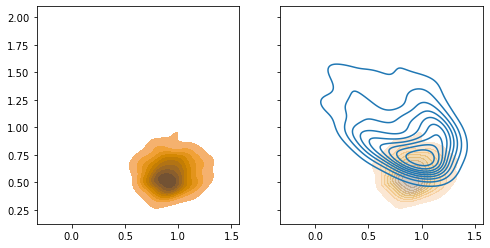

{'epoch': 107, 'iter': 95, 'mmd': 0.172, 'loss': -2.125}
Epoch 106
Epoch 107
Epoch 108
Epoch 109


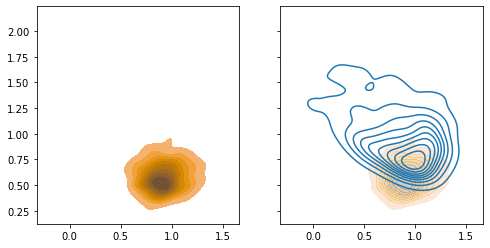

{'epoch': 109, 'iter': 95, 'mmd': 0.174, 'loss': -1.97}
Epoch 108
Epoch 109
Epoch 110
Epoch 111


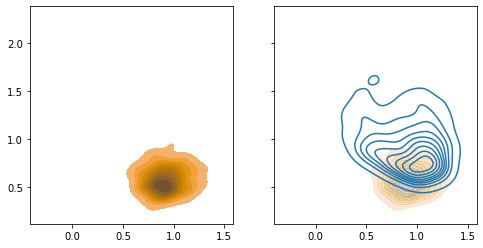

{'epoch': 111, 'iter': 95, 'mmd': 0.18, 'loss': 0.069}
Epoch 110
Epoch 111
Epoch 112
Epoch 113


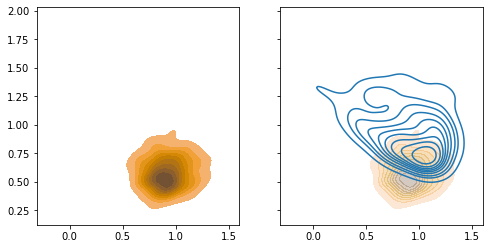

{'epoch': 113, 'iter': 95, 'mmd': 0.192, 'loss': -1.535}
Epoch 112
Epoch 113
Epoch 114
Epoch 115


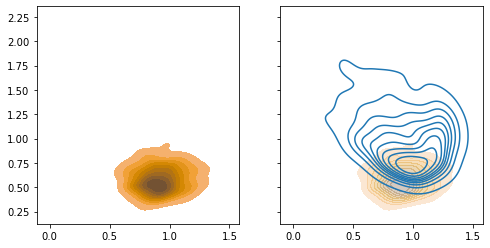

{'epoch': 115, 'iter': 95, 'mmd': 0.208, 'loss': -0.321}
Epoch 114
Epoch 115
Epoch 116
Epoch 117


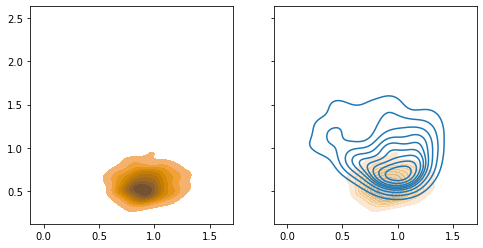

{'epoch': 117, 'iter': 95, 'mmd': 0.168, 'loss': -0.989}
Epoch 116
Epoch 117
Epoch 118
Epoch 119


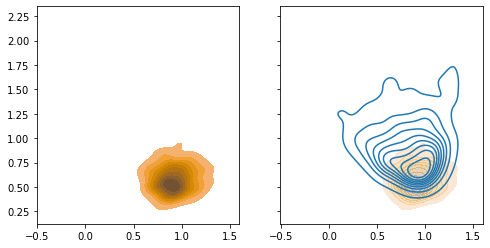

{'epoch': 119, 'iter': 95, 'mmd': 0.131, 'loss': 1.751}
Epoch 118
Epoch 119
Epoch 120
Epoch 121


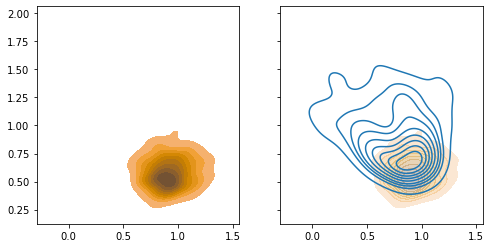

{'epoch': 121, 'iter': 95, 'mmd': 0.133, 'loss': 1.699}
Epoch 120
Epoch 121


In [ ]:
for j in range(300):
    method.train(true_x=x_true, true_thetas=true,
        start_epoch=2*j, end_epoch=2*(j+1)+1, n_iter=100)
    plot(method)
    print(method.qualities[-1])
    
    

<AxesSubplot:>

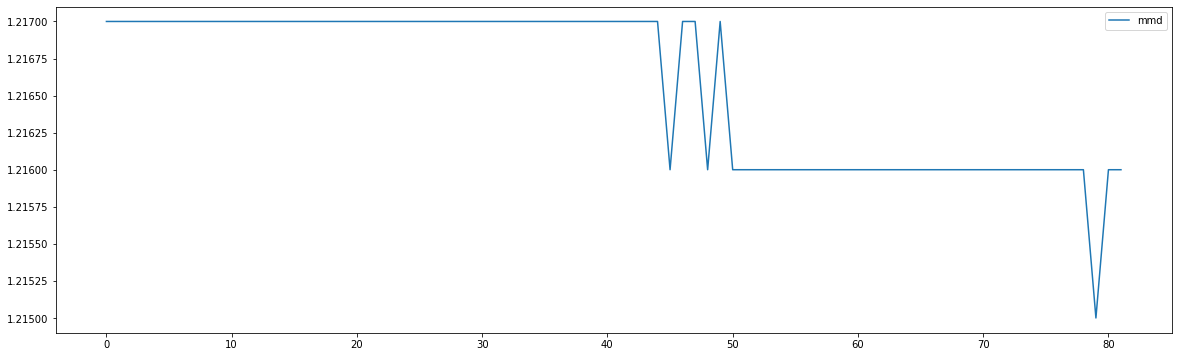

In [69]:
import pandas as pd
pd.DataFrame(method.qualities).plot(y="mmd", figsize=(20,6))

In [10]:
method.save("./results/double_n8.net")

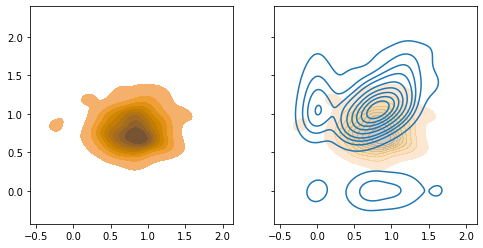

In [11]:
plot(method)